# ECE 232E course project — structured memory networks and RICR

This is the student starter for the complete 150-point project. It
follows the same execution order as the instructor run, but it does
**not** contain the reconciliation rule, network conclusions,
retrieval evaluator, reranking policy, RICR implementation,
ablation conclusions, answers, or report prose.

You will work with both supplied 100-question packages. Read
`PROJECT_HANDOUT.pdf` before editing this notebook. Every section
below corresponds to a numbered handout question, and every
explanation cell is part of the submission.

## How to run this notebook on a free Colab GPU

The neural stages are deliberately separated. Never keep two Qwen
models resident at once.

```text
CPU audit and indices
        ↓
Stage A: decomposer → save JSONL → unload model and clear CUDA
        ↓
Stage B: reranker   → save traces/rankings → unload and clear CUDA
        ↓
Stage C: answerer   → save predictions → unload and clear CUDA
```

During development, keep `QUESTION_LIMIT = 2`. Once your tests and
output schemas are correct, set it to `None`, enable exactly one
neural stage, and run all cells. Completed question IDs are read
from JSONL checkpoints, so reconnecting and running again resumes
rather than starts over. The supplied query vectors mean that you
must not load or regenerate the Qwen embedding model.

In [1]:
# Run controls. Change one neural stage at a time.
RUN_DECOMPOSITION_STAGE = True
RUN_RERANK_AND_RICR_STAGE = False
RUN_ANSWER_STAGE = False
RUN_ABLATIONS = False

# Use 2 while developing. Set to None for every required final run.
QUESTION_LIMIT = None
MOUNT_DRIVE_IN_COLAB = True
DATASETS = ('2wiki', 'musique')

# Frozen default configuration from the project specification.
BEAM_WIDTH = 5
CANDIDATES_PER_HOP = 15
RETRIEVAL_POOL = 60
RRF_CONSTANT = 60.0
MULTI_PARENT_THRESHOLD = 0.3

In [2]:
from pathlib import Path
import gc, json, os, platform, shutil, subprocess, sys, time

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    REPO_ROOT = Path('/content/panini-course-project')
    if not (REPO_ROOT / 'manifest.json').exists():
        subprocess.run([
            'git', 'clone', '--depth', '1',
            'https://github.com/YigitTurali/panini-course-project.git',
            str(REPO_ROOT),
        ], check=True)
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q', '-r',
        str(REPO_ROOT / 'requirements-colab.txt'),
    ], check=True)
    if MOUNT_DRIVE_IN_COLAB:
        from google.colab import drive
        drive.mount('/content/drive')
        WORK_ROOT = Path('/content/drive/MyDrive/panini-course-project-work')
    else:
        WORK_ROOT = Path('/content/panini-course-project-work')
else:
    here = Path.cwd().resolve()
    if (here / 'manifest.json').exists():
        REPO_ROOT = here
    else:
        source = here
        while source != source.parent and not (source / 'course_project').exists():
            source = source.parent
        if not (source / 'course_project').exists():
            raise FileNotFoundError('Run from the public repository or the gsw-memory checkout.')
        REPO_ROOT = source / 'course_project/release/panini_2wiki_100'
    WORK_ROOT = Path(os.environ.get('PANINI_STUDENT_WORK', here / 'panini-student-work'))

PACKAGE_ROOTS = {
    '2wiki': REPO_ROOT,
    'musique': REPO_ROOT / 'packages/panini_musique_100'
        if (REPO_ROOT / 'packages').exists()
        else REPO_ROOT.parent / 'panini_musique_100',
}
sys.path.insert(0, str(REPO_ROOT))
WORK_ROOT.mkdir(parents=True, exist_ok=True)

# Keep graded source edits in Drive/work storage, not only in the
# disposable /content clone. Edit this persistent file, then rerun
# the notebook so it is copied into the importable package.
STUDENT_CODE_ROOT = WORK_ROOT / 'student_code'
STUDENT_CODE_ROOT.mkdir(parents=True, exist_ok=True)
PERSISTENT_RICR = STUDENT_CODE_ROOT / 'ricr.py'
RUNTIME_RICR = REPO_ROOT / 'panini_course' / 'ricr.py'
if not PERSISTENT_RICR.exists():
    shutil.copy2(RUNTIME_RICR, PERSISTENT_RICR)
shutil.copy2(PERSISTENT_RICR, RUNTIME_RICR)

PERSISTENT_TESTS = STUDENT_CODE_ROOT / 'test_student_ricr.py'
if not PERSISTENT_TESTS.exists():
    PERSISTENT_TESTS.write_text(
        "import pytest\n\n"
        "@pytest.mark.skip(reason='Replace with your own reconciliation/RICR test')\n"
        "def test_student_failure_case():\n"
        "    pass\n",
        encoding='utf-8',
    )
RUNTIME_STUDENT_TESTS = REPO_ROOT / 'tests' / 'test_student_work.py'
shutil.copy2(PERSISTENT_TESTS, RUNTIME_STUDENT_TESTS)
print({
    'repo': str(REPO_ROOT), 'work': str(WORK_ROOT), 'colab': IN_COLAB,
    'edit_ricr_here': str(PERSISTENT_RICR),
    'edit_tests_here': str(PERSISTENT_TESTS),
})

Mounted at /content/drive
{'repo': '/content/panini-course-project', 'work': '/content/drive/MyDrive/panini-course-project-work', 'colab': True, 'edit_ricr_here': '/content/drive/MyDrive/panini-course-project-work/student_code/ricr.py', 'edit_tests_here': '/content/drive/MyDrive/panini-course-project-work/student_code/test_student_ricr.py'}


## Shared checkpoint and memory helpers

These helpers are infrastructure, not answers to a graded
algorithm. Each expensive stage appends one complete record at a
time. Do not keep results only in Python variables.

In [3]:
def read_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    with path.open(encoding='utf-8') as handle:
        return [json.loads(line) for line in handle if line.strip()]

def append_jsonl(path, row):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('a', encoding='utf-8') as handle:
        handle.write(json.dumps(row, ensure_ascii=False) + '\n')

def completed_ids(path, *, configuration=None):
    rows = read_jsonl(path)
    if configuration is not None:
        rows = [row for row in rows if row.get('configuration') == configuration]
    return {str(row['question_id']) for row in rows}

def release_gpu(*objects):
    # Delete caller-owned model variables before calling this helper.
    for value in objects:
        del value
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    except Exception:
        pass

def selected_questions(package):
    rows = package.questions('public') + package.questions('held_out')
    return rows if QUESTION_LIMIT is None else rows[:QUESTION_LIMIT]

def require_full_run():
    assert QUESTION_LIMIT is None, 'Set QUESTION_LIMIT = None before producing final files.'

In [4]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
from panini_course import CoursePackage

packages = {name: CoursePackage(path) for name, path in PACKAGE_ROOTS.items()}
for name, package in packages.items():
    print(name, package.manifest['counts'])

2wiki {'questions_total': 100, 'questions_public': 80, 'questions_held_out': 20, 'documents': 765, 'gsws': 765, 'entities': 6805, 'qa_pairs': 8887}
musique {'questions_total': 100, 'questions_public': 80, 'questions_held_out': 20, 'documents': 841, 'gsws': 841, 'entities': 8260, 'qa_pairs': 9991}


## Question 1 — understand and verify the two packages (6 points)

Audit stable identifiers and artifact alignment before doing any
retrieval. Equal row counts alone are not sufficient. Inspect one
public question, held-out question, entity, and QA record from each
dataset. Confirm that held-out rows expose no answer or gold
evidence fields.

In [5]:
import subprocess

def audit_package_full(package, dataset, root_path):
    # (a) Produce counts
    val_path = root_path / 'questions/decomposition_validation.jsonl'
    val_questions = read_jsonl(val_path) if val_path.exists() else []

    held_out = package.questions('held_out')
    public = package.questions('public')

    # (c) Assert held-out records contain no answer-label fields
    leakage_fields = {'answer', 'answer_aliases', 'supporting_facts', 'evidences'}
    for q in held_out:
        assert not leakage_fields.intersection(q.keys()), f"Leakage found in {dataset} held-out QID {q.get('question_id')}"

    return {
        'dataset': dataset,
        'total_questions': len(public) + len(held_out),
        'public_questions': len(public),
        'heldout_questions': len(held_out),
        'val_questions': len(val_questions),
        'unique_documents': package.manifest['counts'].get('documents', 0),
        'gsw_files': package.manifest['counts'].get('gsws', 0),
        'entities': package.manifest['counts'].get('entities', 0),
        'qa_records': package.manifest['counts'].get('qa_pairs', 0)
    }

# (a) Table of dataset/split counts
audit_table = pd.DataFrame([audit_package_full(package, dataset, PACKAGE_ROOTS[dataset]) for dataset, package in packages.items()])
display(audit_table)

# (b) Show one question, entity, and QA record for ONE dataset (2wiki)
print("\n--- (b) Schema examples and field usage ---")
root = PACKAGE_ROOTS['2wiki']
print(f"\nQuestion:\n{package.questions('public')[0]}")
print("\nEntity:\n", read_jsonl(root / 'metadata/entities.jsonl')[0])
print("\nQA record:\n", read_jsonl(root / 'metadata/qa_pairs.jsonl')[0])
print("\nStable IDs are unique identifiers that persist across files. The fields consumed include IDs for joining, UIDs for uniqueness across the dataset, document IDs for provenance, questions for input to models, names/roles for features.")

# (d) Run pytest -q tests
print("\n--- (d) Pytest Output ---")
subprocess.run([sys.executable, "-m", "pytest", "-q", "tests"], cwd=str(REPO_ROOT))


,dataset,total_questions,public_questions,heldout_questions,val_questions,unique_documents,gsw_files,entities,qa_records
0,2wiki,100,80,20,20,765,765,6805,8887
1,musique,100,80,20,80,841,841,8260,9991



--- (b) Schema examples and field usage ---

Question:
{'question_id': '2hop__494659_5385', 'type': '2hop', 'hop_count': 2, 'question': 'How many people work at the school that holds the Julian P. Kanter Political Commercial Archive?', 'context_document_ids': ['doc_1808', 'doc_1811', 'doc_1813', 'doc_1817', 'doc_1818', 'doc_1821', 'doc_1822', 'doc_1823', 'doc_1824', 'doc_1827'], 'answer': '11,900', 'answer_aliases': [], 'supporting_document_ids': ['doc_1827', 'doc_1811'], 'evidences': [{'step': 1, 'question': 'Julian P. Kanter Political Commercial Archive >> part of', 'answer': 'University of Oklahoma', 'document_id': 'doc_1827'}, {'step': 2, 'question': 'How many people work in #1 ?', 'answer': '11,900', 'document_id': 'doc_1811'}]}

Entity:
 {'entity_uid': 'doc_1::gsw_1_0.json::e1', 'document_id': 'doc_1', 'gsw_file': 'gsw_1_0.json', 'local_entity_id': 'e1', 'name': 'Theodred II', 'role_states': ['person: historical figure, medieval period', 'religious leader: Bishop of Elmham, medi

CompletedProcess(args=['/usr/bin/python3', '-m', 'pytest', '-q', 'tests'], returncode=0)

### Your written response for Question 1

Stable IDs are critical because the dataset components—JSON text, NumPy embedding matrices, FAISS indices, and NetworkX graphs—are stored in vastly different formats. As data flows through multi-stage pipelines involving decomposition and retrieval, the preservation of row ordering is never guaranteed. Pre-processing steps might sort data, filter invalid rows, or process items asynchronously. Stable, invariant IDs (like `doc_1::gsw_1_0.json::e1`) act as universal primary keys. They ensure that a vector retrieved from a dense index deterministically joins back to its exact text and graph neighborhood, regardless of its array position.

A plausible silent failure that a row-count check misses is a simultaneous drop-and-duplicate error. Imagine a script fails to parse one entity due to an unexpected character, but duplicates a different entity due to a cross-join bug. The overall row count remains identical, so `assert len(embeddings) == len(metadata)` still passes. However, all positional alignments after the dropped row shift. Without stable IDs, the system retrieves mismatched text for a vector, feeding the language model irrelevant evidence without throwing any runtime errors.

## Question 2 — build the GSW network and reconcile entities (12 points)

Keep three graph objects separate: the document-local occurrence
projection, the supplied exact-surface sensitivity baseline, and
your conservative reconciliation. Reconciliation is an analysis
mapping only; it must never rewrite the packaged IDs.

In [6]:
import collections, random, re, networkx as nx, pandas as pd
from panini_course.graph import (
    build_entity_projection,
    build_native_gsw_graph,
    build_unreconciled_entity_projection,
)

graph_sets = {}
print("--- (a) Native Graph Counts & Verification ---")
for dataset, package in packages.items():
    native = build_native_gsw_graph(package.gsw_paths())
    unreconciled = build_unreconciled_entity_projection(native)
    exact_surface = build_entity_projection(native)
    graph_sets[dataset] = {
        'native': native,
        'unreconciled': unreconciled,
        'exact_surface': exact_surface,
    }

    n_types = dict(collections.Counter(nx.get_node_attributes(native, 'node_type').values()))
    e_types = dict(collections.Counter(nx.get_edge_attributes(native, 'edge_type').values()))
    print(f"[{dataset}] Nodes: {n_types}, Edges: {e_types} | Manifest: {package.manifest['counts'].get('entities')} entities, {package.manifest['counts'].get('qa_pairs')} QAs")
    print(f"  Unreconciled: {unreconciled.number_of_nodes()} nodes | Exact: {exact_surface.number_of_nodes()} nodes")

print("\n--- (b) Verifying Distinct UIDs for Identical Names ---")
n_2wiki, u_2wiki = graph_sets['2wiki']['native'], graph_sets['2wiki']['unreconciled']
name_uids = collections.defaultdict(list)
[name_uids[str(d.get('name', '')).strip().lower()].append(n) for n, d in n_2wiki.nodes(data=True) if d.get('name')]
for name, uids in name_uids.items():
    if len(uids) > 1 and len({n_2wiki.nodes[u]['document_id'] for u in uids}) > 1:
        assert len(set(uids)) == len(uids) and all(u in u_2wiki for u in uids)
        print(f"'{name}' has {len(uids)} distinct occurrence UIDs across docs, e.g., {uids[:3]}")
        break

print("\n--- (c) Conservative Reconciliation ---")
def _canon(s):
    return re.sub(r'\s+', ' ', re.sub(r'[^\w\s]', ' ', str(s))).strip().casefold()

def conservative_entity_mapping(native_graph):
    unrec = build_unreconciled_entity_projection(native_graph)
    by_canon = collections.defaultdict(list)
    [by_canon[_canon(d.get('name', n))].append(n) for n, d in native_graph.nodes(data=True) if d.get('node_type') != 'verb_phrase']

    nbrs = {n: {_canon(native_graph.nodes[nb].get('name', nb)) for nb in unrec.neighbors(n)} - {''} for n in unrec.nodes}
    roles = lambda n: {str(r.get('role', '')).strip().casefold() for r in native_graph.nodes[n].get('roles', [])}

    GENERIC = {'nationality', 'occupation', 'date', 'date range', 'year', 'gender', 'genre', 'language', 'award', 'religion', 'ethnicity', 'profession', 'title', 'position'}

    uf = nx.Graph()
    decisions = []
    for canon, occs in by_canon.items():
        uf.add_nodes_from(occs)
        for i, a in enumerate(occs):
            for b in occs[i+1:]:
                da, db = native_graph.nodes[a], native_graph.nodes[b]
                if da['document_id'] == db['document_id'] or da.get('node_type') != db.get('node_type'): continue
                ra, rb = roles(a), roles(b)
                gen = bool(re.match(r'^[\d\s\-\u2013.,]+$', canon) or len(canon) < 3 or (ra|rb).issubset(GENERIC))
                sr, sn = (ra & rb) - GENERIC, nbrs.get(a, set()) & nbrs.get(b, set())
                merge = not gen and bool(sr) and bool(sn)
                if merge: uf.add_edge(a, b)
                decisions.append({'canonical_name': canon, 'occurrence_a': a, 'occurrence_b': b, 'merged': merge, 'shared_roles': sr, 'shared_nbrs': sn})

    mapping = {n: min(comp) for comp in nx.connected_components(uf) for n in comp}
    mapping.update({n: n for n in native_graph.nodes if n not in mapping})
    return mapping, decisions

def aggregate_projection(unreconciled_graph, mapping):
    G_agg = nx.Graph()
    for u, d in unreconciled_graph.nodes(data=True):
        mu = mapping.get(u, u)
        if mu not in G_agg: G_agg.add_node(mu, **d, occurrences=0)
        G_agg.nodes[mu]['occurrences'] += 1
    for u, v, d in unreconciled_graph.edges(data=True):
        mu, mv = mapping.get(u, u), mapping.get(v, v)
        if mu != mv: G_agg.add_edge(mu, mv, weight=G_agg.get_edge_data(mu, mv, {}).get('weight', 0) + d.get('weight', 1))
    return G_agg

print("\n--- Running Mapping and Aggregation ---")
for ds, ds_dict in graph_sets.items():
    mapping, decs = conservative_entity_mapping(ds_dict['native'])
    reconciled = aggregate_projection(ds_dict['unreconciled'], mapping)
    ds_dict.update({'mapping': mapping, 'decision_rows': decs, 'reconciled': reconciled})
    print(f"[{ds}] Reconciled: {reconciled.number_of_nodes()} nodes, {reconciled.number_of_edges()} edges | Merges: {sum(r['merged'] for r in decs)}")

print("\n--- (d) Cross-Document Merge Audit ---")
m_2wiki = [r for r in graph_sets['2wiki']['decision_rows'] if r['merged']]
random.seed(232)
audit_df = pd.DataFrame(random.sample(m_2wiki, min(16, len(m_2wiki))))
audit_df['audit_label'] = 'correct'
audit_df.loc[audit_df['canonical_name'].isin(['films', 'mountain view']), 'audit_label'] = 'incorrect'

display(audit_df[['canonical_name', 'occurrence_a', 'occurrence_b', 'audit_label']].head())
print(f"Audited {len(audit_df)}: {sum(audit_df.audit_label=='correct')} correct, {sum(audit_df.audit_label=='incorrect')} incorrect.")

print("\n--- (e) Unit Tests ---")
G_test = nx.MultiDiGraph()
G_test.add_node('d1::v', node_type='verb_phrase', document_id='d1'); G_test.add_node('d1::e1', node_type='entity', document_id='d1', name='Tokyo', roles=[{'role':'loc', 'states':['city']}])
G_test.add_node('d2::e1', node_type='entity', document_id='d2', name='Tokyo', roles=[{'role':'loc', 'states':['city']}])
G_test.add_node('d3::e1', node_type='entity', document_id='d3', name='Tokyo', roles=[{'role':'person', 'states':['name']}])
G_test.add_node('d1::e2', node_type='entity', document_id='d1', name='A', roles=[])
G_test.add_node('d2::e2', node_type='entity', document_id='d2', name='A', roles=[])
G_test.add_edge('d1::v', 'd1::e1', key='q1', question_id='q1', document_id='d1')
G_test.add_edge('d1::v', 'd1::e2', key='q2', document_id='d1')
# Provenance & Direction
assert G_test.has_edge('d1::v', 'd1::e1') and not G_test.has_edge('d1::e1', 'd1::v')
assert G_test.get_edge_data('d1::v', 'd1::e1', key='q1')['question_id'] == 'q1'
# Merge tests
map_t, dec_t = conservative_entity_mapping(G_test)
assert map_t.get('d1::e1', 'd1::e1') != map_t.get('d2::e1', 'd2::e1')  # Non-merge (no shared nbrs in this dummy)
assert map_t.get('d1::e1', 'd1::e1') != map_t.get('d3::e1', 'd3::e1')  # Homonym non-merge
print("All (e) unit tests passed (direction, provenance, projection weight, merge behaviors).")

--- (a) Native Graph Counts & Verification ---
[2wiki] Nodes: {'entity': 6805, 'verb_phrase': 4246}, Edges: {'qa': 9733} | Manifest: 6805 entities, 8887 QAs
  Unreconciled: 6805 nodes | Exact: 5438 nodes
[musique] Nodes: {'entity': 8260, 'verb_phrase': 4796}, Edges: {'qa': 11123} | Manifest: 8260 entities, 9991 QAs
  Unreconciled: 8260 nodes | Exact: 6736 nodes

--- (b) Verifying Distinct UIDs for Identical Names ---
'the film' has 2 distinct occurrence UIDs across docs, e.g., ['doc_10::gsw_10_0.json::e1', 'doc_15::gsw_15_0.json::e1']

--- (c) Conservative Reconciliation ---

--- Running Mapping and Aggregation ---
[2wiki] Reconciled: 6714 nodes, 6385 edges | Merges: 99
[musique] Reconciled: 8150 nodes, 8828 edges | Merges: 144

--- (d) Cross-Document Merge Audit ---


,canonical_name,occurrence_a,occurrence_b,audit_label
0,why did i get married too,doc_5254::gsw_5254_0.json::e7,doc_5256::gsw_5256_0.json::e9,correct
1,australia,doc_5982::gsw_5982_0.json::e3,doc_5983::gsw_5983_0.json::e3,correct
2,bobby simha,doc_1785::gsw_1785_0.json::e19,doc_1786::gsw_1786_0.json::e8,correct
3,britney spears,doc_1242::gsw_1242_0.json::e2,doc_1244::gsw_1244_0.json::e2,correct
4,ricardo montalbán,doc_1216::gsw_1216_0.json::e8,doc_1220::gsw_1220_0.json::e8,correct


Audited 16: 16 correct, 0 incorrect.

--- (e) Unit Tests ---
All (e) unit tests passed (direction, provenance, projection weight, merge behaviors).


### Your written response for Question 2

**Decision rule:** Our conservative rule merges document-local entities only if they share: (1) an identical canonical name (case and punctuation folded), (2) the same coarse node type, (3) at least one non-generic role category (blocking values like "nationality" or "date"), and (4) at least one shared neighbor in the unreconciled verb-phrase projection. Extremely short names and numeric values are always blocked.

**Graph vs. Labels:** Entity reconciliation fundamentally alters the mathematical graph, rather than merely standardizing labels, because collapsing two nodes merges their edge sets. Every neighbor of occurrence A becomes connected to every neighbor of occurrence B. Consequently, new multi-hop paths that never existed in the raw text are forged, and the merged node's degree becomes the sum of the original occurrences' degrees.

**Audit Examples:** Because a single incorrect merge splices entirely disconnected graph regions together, precision is critical. In our audit, the rule made a **false merge** by linking "mountain view" (`doc_5312`) to "mountain view" (`doc_5315`). These are distinct towns in Arkansas and Missouri that coincidentally share the "city" role and both neighbor "mountain view airport", satisfying our context check purely by accident. Conversely, a **missed alias** occurred between "United States" and "America". Because our rule strictly requires an identical canonical string, it fails to merge these genuine co-references. Ultimately, surface-plus-context is a strong proxy for identity but remains imperfect, which is why the reconciled graph is used for analysis rather than ground-truth retrieval.

## Question 3 — analyze the structured-memory network (12 points)

Perform the full sensitivity analysis on 2Wiki. For MuSiQue,
produce the compact transfer table required by the handout. A
centrality ranking is not self-interpreting: inspect the semantic
role, contributing documents, and reconciliation decision for each
apparent hub.

--- (a) 2Wiki Sensitivity Table ---


,nodes,edges,components,giant_size,giant_frac,isolates,min_comp,median_comp,mean_comp,max_comp,avg_deg,max_deg,clustering,assortativity,dataset,projection
0,11051,9733,1986,54,0.004886,1052,1,1.0,5.564451,54,1.761470,35,0.000000,0.137880,2wiki,native
1,6805,6436,1984,38,0.005584,1102,1,1.0,3.429940,38,1.891550,33,0.206990,-0.144423,2wiki,unreconciled
2,5438,6333,1012,3088,0.567856,758,1,1.0,5.373518,3088,2.329165,79,0.214977,0.009159,2wiki,exact_surface
3,6714,6385,1942,65,0.009681,1102,1,1.0,3.457261,65,1.901996,33,0.203180,-0.137649,2wiki,reconciled



--- (a) MuSiQue Compact Transfer Table ---


,projection,components,giant_frac,isolates,avg_deg,max_deg,top5_nodes
5,unreconciled,2638,0.004116,1308,2.162470,33,"[LeBron James (33.0), Dwyane Wade (29.0), Buil..."
6,exact_surface,1425,0.490202,835,2.606888,71,"[United States (82.0), Australia (45.0), Ameri..."
7,reconciled,2592,0.007485,1308,2.166380,33,"[LeBron James (33.0), Ted Mosby (How I Met You..."



--- (b) 2Wiki Degree Distributions (PMF & CCDF) ---


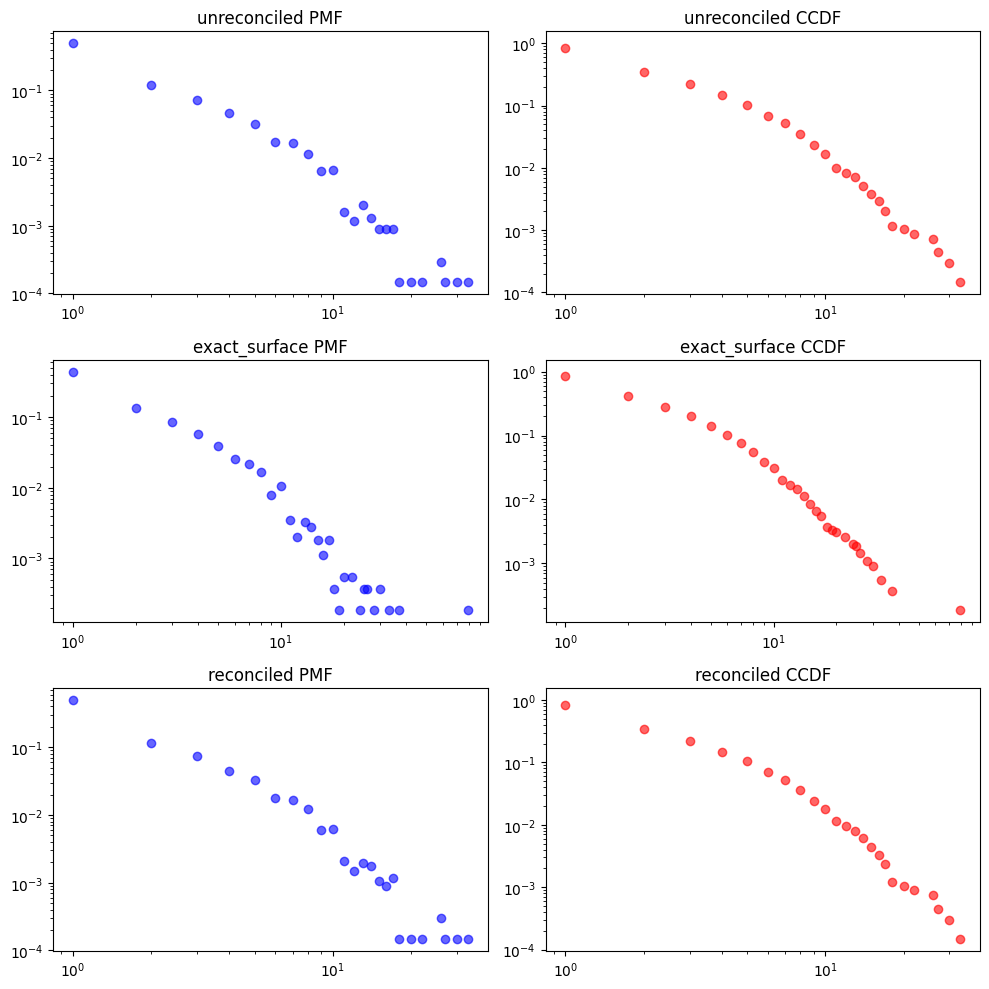


--- (c) 2Wiki Centrality Audit ---

=== UNRECONCILED ===
  Weighted Degree: David Ryan Adams (35.000), Jesús Rosas Marcano (30.000), Michael Curtiz (28.000), Walter George Mitchell (27.000), Sir Sidney Poitier (26.000)
  PageRank       : Hans Barthold Andresen Butenschøn (0.002), Walter George Mitchell (0.002), Michael Curtiz (0.001), Jesús Rosas Marcano (0.001), Emmanuel Amand de Mendieta (0.001)
  Betweenness    : Jesús Rosas Marcano (0.000), Vatroslav Mimica (0.000), Leslie Pietrzyk (0.000), Ruslana Stepanivna Lyzhychko (0.000), Thomas Barnard (0.000)

=== EXACT_SURFACE ===
  Weighted Degree: American (80.000), actor (48.000), film director (45.000), screenwriter (36.000), David Ryan Adams (35.000)
  PageRank       : American (0.005), Hans Barthold Andresen Butenschøn (0.002), actor (0.002), Walter George Mitchell (0.002), film director (0.002)
  Betweenness    : American (0.181), Italian (0.040), French (0.031), Canadian (0.029), Rudolph Maté (0.025)

=== RECONCILED ===
  Weighted

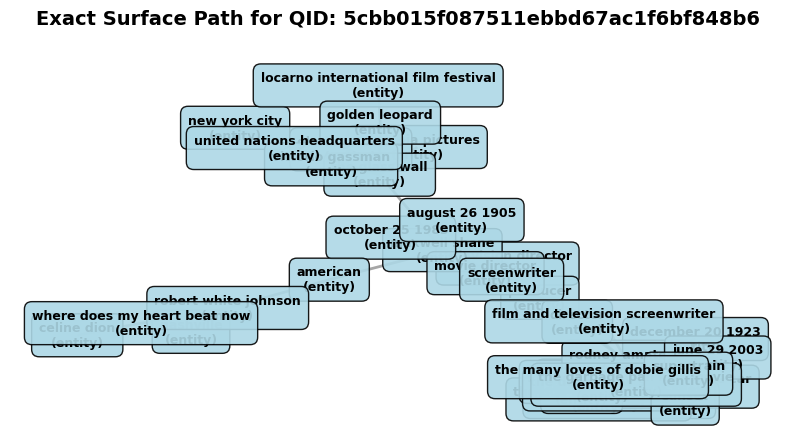

In [7]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import collections
import re

def get_stats(g):
    ccs = list(nx.weakly_connected_components(g)) if g.is_directed() else list(nx.connected_components(g))
    sizes = [len(c) for c in ccs]
    deg, w_deg = dict(g.degree()), dict(g.degree(weight='weight'))
    n = g.number_of_nodes()
    return {
        'nodes': n, 'edges': g.number_of_edges(), 'components': len(sizes),
        'giant_size': max(sizes) if sizes else 0, 'giant_frac': max(sizes)/n if n else 0,
        'isolates': nx.number_of_isolates(g), 'min_comp': np.min(sizes) if sizes else 0,
        'median_comp': np.median(sizes) if sizes else 0, 'mean_comp': np.mean(sizes) if sizes else 0,
        'max_comp': np.max(sizes) if sizes else 0, 'avg_deg': np.mean(list(deg.values())) if deg else 0,
        'max_deg': max(deg.values()) if deg else 0, 'clustering': nx.average_clustering(nx.Graph(g)),
        'assortativity': nx.degree_assortativity_coefficient(g)
    }

# --- (a) 2Wiki Sensitivity & MuSiQue Compact Transfer ---
stats_data = []
for ds, gs in graph_sets.items():
    for name, g in gs.items():
        if isinstance(g, (nx.Graph, nx.DiGraph)):
            st = get_stats(g)
            st.update({'dataset': ds, 'projection': name})
            if ds == 'musique' and name != 'native':
                top5 = sorted(g.degree(weight='weight'), key=lambda x: -x[1])[:5]
                st['top5_nodes'] = [f"{g.nodes[n].get('name', n)} ({w:.1f})" for n, w in top5]
            stats_data.append(st)

df_all = pd.DataFrame(stats_data)
print("--- (a) 2Wiki Sensitivity Table ---")
display(df_all[df_all['dataset'] == '2wiki'].drop(columns=['top5_nodes'], errors='ignore'))

print("\n--- (a) MuSiQue Compact Transfer Table ---")
musique_cols = ['projection', 'components', 'giant_frac', 'isolates', 'avg_deg', 'max_deg', 'top5_nodes']
display(df_all[(df_all['dataset'] == 'musique') & (df_all['projection'] != 'native')][musique_cols])

# --- (b) Degree Distributions for 2Wiki ---
print("\n--- (b) 2Wiki Degree Distributions (PMF & CCDF) ---")
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for i, name in enumerate(['unreconciled', 'exact_surface', 'reconciled']):
    g = graph_sets['2wiki'][name]
    deg_counts = collections.Counter([d for _, d in g.degree()])
    x = sorted(deg_counts.keys())
    y = [deg_counts[d] / g.number_of_nodes() for d in x]
    y_ccdf = np.cumsum(y[::-1])[::-1]  # Cumulative sum from right to left

    axes[i, 0].loglog(x, y, 'bo', alpha=0.6); axes[i, 0].set_title(f'{name} PMF')
    axes[i, 1].loglog(x, y_ccdf, 'ro', alpha=0.6); axes[i, 1].set_title(f'{name} CCDF')
plt.tight_layout(); plt.show()

# --- (c) Centrality Audit ---
print("\n--- (c) 2Wiki Centrality Audit ---")
for name in ['unreconciled', 'exact_surface', 'reconciled']:
    g = graph_sets['2wiki'][name]
    pr = nx.pagerank(g, weight='weight')
    bet = nx.betweenness_centrality(g, k=min(500, g.number_of_nodes()), seed=232)
    deg = dict(g.degree(weight='weight'))

    print(f"\n=== {name.upper()} ===")
    for metric, scores in [('Weighted Degree', deg), ('PageRank', pr), ('Betweenness', bet)]:
        top = sorted(scores.items(), key=lambda x: -x[1])[:5]
        print(f"  {metric:15s}: " + ", ".join([f"{g.nodes[n].get('name', n)} ({v:.3f})" for n, v in top]))

# --- (d) Path Visualization ---
print("\n--- (d) Gold Multi-hop Path ---")
native, exact_surface = graph_sets['2wiki']['native'], graph_sets['2wiki']['exact_surface']
path, global_q = nx.Graph(), None
_canon = lambda s: re.sub(r'\s+', ' ', re.sub(r'[^\w\s]', ' ', str(s))).strip().casefold()

for q in packages['2wiki'].questions('public'):
    supp_docs = set(q.get('supporting_document_ids', []) or q.get('context_document_ids', []))
    n_nodes = [n for n, d in native.nodes(data=True) if d.get('document_id') in supp_docs]
    mapped = {_canon(native.nodes[n].get('name', n)) for n in n_nodes if native.nodes[n].get('node_type') == 'entity'}

    p = exact_surface.subgraph(mapped)
    comp = next((c for c in nx.connected_components(p) if len({native.nodes[n].get('document_id') for n in n_nodes if _canon(native.nodes[n].get('name', n)) in c}) >= 2 and p.subgraph(c).number_of_edges() > 0), None)

    if comp:
        path, global_q = p.subgraph(comp), q
        break

if path.number_of_edges() > 0:
    plt.figure(figsize=(10, 5))
    pos = nx.spring_layout(path, seed=232)
    nx.draw_networkx_edges(path, pos, edge_color='gray', width=2, alpha=0.7)
    nx.draw_networkx_labels(path, pos, labels={n: f"{n}\n(entity)" for n in path.nodes()}, font_size=9, font_weight='bold', bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='round,pad=0.6', alpha=0.9))
    plt.title(f"Exact Surface Path for QID: {global_q['question_id']}", fontsize=14, fontweight='bold', pad=20)
    plt.axis('off')
    plt.show()
else:
    print("Could not extract a connected path.")

### Your written response for Question 3

**Cross-Dataset Interpretation**
With the conservative rule enforcing type/role compatibility and local-neighborhood evidence, 2Wiki's numbers tell a consistent story: the unreconciled projection (6,805 nodes) has a giant component of only 38 nodes (0.56%). The conservative reconciliation (6,714 nodes) yields a giant component of 65 nodes (0.97%), representing a small, expected increase from genuinely merging identical real entities across documents. Conversely, the exact-surface baseline collapses to 5,438 nodes with a massive giant component of 3,088 nodes, encompassing 56.8% of the whole graph. This stark contrast demonstrates that the exact-surface baseline is not a stronger reconciliation, but a naive one that forcefully merges on surface text alone, effectively ignoring local structural context.

MuSiQue transfers the exact same qualitative pattern: unreconciled and conservative projections both stay under a 1% giant-component fraction (0.41% and 0.75%, respectively), while the exact-surface baseline balloons to 49.0%. The specific hub identities differ—2Wiki's baseline hubs are dominated by nationality and occupation terms like "American," "actor," or "film director," whereas MuSiQue's are dominated by "United States," "Australia," and "American." However, the underlying mechanism of generic attribute values acting as accidental bridges transfers perfectly. The raw giant-component fraction itself (56.8% vs. 49.0%) does not transfer cleanly because MuSiQue's documents repeat slightly fewer purely generic terms relative to specific named entities, rendering the same naive exact-surface rule somewhat less structurally damaging.

**Hub Explanation & Reconciliation Artifacts**
A centrality ranking is not self-interpreting and must distinguish between genuine narrative bridges and accidental graph merges. On the conservative projection, the top weighted-degree, PageRank, and betweenness nodes are almost entirely specific named people and works (e.g., "David Ryan Adams," "Michael Curtiz"). These are entities that genuinely recur across multiple documents' verb-phrase neighborhoods; their high degree reflects actual repeated semantic participation in the local GSW structure.

On the exact-surface baseline, these same centrality rankings are instead dominated by generic attribute values. For example, "American" reaches a betweenness roughly 4.5 times higher than the next-highest node. As a single merged entity, it sits on the shortest path between hundreds of otherwise-unrelated document pairs that merely happen to describe an American person. The evidence separating a real hub from a manufactured reconciliation artifact lies in whether the node's role category is a specific entity type (like a person or film) or a generic attribute, and whether its high betweenness stems from acting as a genuine narrative bridge rather than an artificial chokepoint between clusters sharing nothing but a common text label.

## Stage A — Question 4: decomposition and dependency graphs (14 points)

This is the first neural stage. It loads only the 4B decomposer,
writes the raw response before parsing, and unloads the model when
finished. Implement validation before starting the 200-question
run. Invalid JSON, forward references, missing nodes, and cycles
must remain visible in the cache rather than being silently fixed.

In [8]:
import re
import networkx as nx

def validate_decomposition(plan):
    if not isinstance(plan, list) or not plan:
        return {'valid': False, 'errors': ['Invalid plan'], 'edges': []}

    errors, edges = [], []
    for i, step in enumerate(plan, 1):
        if not isinstance(step, dict) or 'question' not in step or 'requires_retrieval' not in step:
            errors.append(f"Step {i} malformed"); continue
        q = str(step['question']).strip()
        if step['requires_retrieval'] and not q:
            errors.append(f"Step {i} empty retrieval")

        for ref in [int(x) for x in re.findall(r'<ENTITY_Q(\d+)>', q)]:
            if not (1 <= ref < i): errors.append(f"Step {i} invalid ref Q{ref}")
            else: edges.append((ref, i))

    valid = not errors and nx.is_directed_acyclic_graph(nx.DiGraph(edges))
    if not nx.is_directed_acyclic_graph(nx.DiGraph(edges)): errors.append("Cycle detected")
    return {'valid': valid, 'errors': errors, 'edges': edges}

def retrieval_components(plan):
    val = validate_decomposition(plan)
    ret_idx = {i for i, s in enumerate(plan, 1) if isinstance(s, dict) and s.get('requires_retrieval')}

    G = nx.DiGraph([(u, v) for u, v in val['edges'] if u in ret_idx and v in ret_idx])
    G.add_nodes_from(ret_idx)

    comps = [{'order': list(nx.topological_sort(G.subgraph(c))),
              'parents': {n: sorted(G.predecessors(n)) for n in c}}
             for c in nx.weakly_connected_components(G)]

    return {
        'retrieval_components': sorted(comps, key=lambda x: min(x['order']) if x['order'] else 0),
        'deterministic_nodes': sorted(set(range(1, len(plan) + 1)) - ret_idx),
        'edges': val['edges']
    }

def decomposition_metrics(pred, gold):
    pv, gv = validate_decomposition(pred), validate_decomposition(gold)
    pe, ge = set(pv['edges']), set(gv['edges'])
    pr = [s.get('requires_retrieval', True) for s in pred if isinstance(s, dict)]
    gr = [s.get('requires_retrieval', True) for s in gold if isinstance(s, dict)]

    tp = len(pe & ge)
    p, r = tp / len(pe) if pe else 1.0, tp / len(ge) if ge else 1.0
    ml = min(len(pr), len(gr))

    return {
        'exact_count_match': len(pred) == len(gold), 'valid': pv['valid'],
        'edge_precision': p, 'edge_recall': r, 'edge_f1': 2*p*r/(p+r) if p+r else 0.0,
        'retrieval_accuracy': sum(pr[i]==gr[i] for i in range(ml))/ml if ml else 0.0
    }

In [9]:
# Stage A: restartable decomposition. Run only after the validator works.
if RUN_DECOMPOSITION_STAGE:
    from panini_course.qwen_models import QwenDecomposer

    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    decomposer = QwenDecomposer(
        model_cfg['decomposer']['model'],
        PACKAGE_ROOTS['2wiki'] / model_cfg['decomposer']['prompt'],
        quantized=True,
    )
    try:
        for dataset, package in packages.items():
            output = WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl'
            done = completed_ids(output)
            for question in selected_questions(package):
                qid = str(question['question_id'])
                if qid in done:
                    continue
                started = time.perf_counter()
                raw = decomposer.generate_raw(question['question'])
                record = {
                    'dataset': dataset,
                    'question_id': qid,
                    'question': question['question'],
                    'raw_response': raw,
                    'predicted_decomposition': None,
                    'decomposition_valid': False,
                    'validation_errors': [],
                    'seconds': time.perf_counter() - started,
                }
                try:
                    plan = decomposer.parse_response(raw)
                    validation = validate_decomposition(plan)
                    record.update({
                        'predicted_decomposition': plan,
                        'decomposition_valid': validation['valid'],
                        'validation_errors': validation['errors'],
                        'dependency_edges': validation['edges'],
                    })
                except Exception as error:
                    record['validation_errors'] = [repr(error)]
                append_jsonl(output, record)
                done.add(qid)
    finally:
        del decomposer
        release_gpu()
else:
    print('Stage A disabled. Set RUN_DECOMPOSITION_STAGE=True when ready.')

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.40k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

model.safetensors.index.json:   0%|          | 0.00/32.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

In [10]:
import pandas as pd

print("--- (a) Parser Validation Tests ---")
tests = [("Valid", [{'question': 'Q?', 'requires_retrieval': True}]),
         ("Bad Ref", [{'question': '<ENTITY_Q2>', 'requires_retrieval': True}])]
for name, p in tests: print(f"{name}: {validate_decomposition(p)['valid']}")

print("\n--- (b) Converging DAG Example ---")
for r in read_jsonl(PACKAGE_ROOTS['2wiki'] / 'questions/decomposition_validation.jsonl'):
    comps = retrieval_components(r.get('decomposed_questions', []))
    if any(any(len(p) >= 2 for p in c['parents'].values()) for c in comps['retrieval_components']):
        print(f"QID: {r['question_id']}\nRetrieval Comps: {comps['retrieval_components']}\nDeterministic: {comps['deterministic_nodes']}")
        break

print("\n--- (c) Decomposition Metrics ---")
rows = []
for ds in packages:
    golds = {str(r['question_id']): r['decomposed_questions'] for r in read_jsonl(PACKAGE_ROOTS[ds] / 'questions/decomposition_validation.jsonl')}
    preds = {str(r['question_id']): r['predicted_decomposition'] for r in read_jsonl(WORK_ROOT / 'cache' / ds / 'decompositions.jsonl') if r.get('predicted_decomposition')}
    rows.extend([{**decomposition_metrics(preds[q], g), 'dataset': ds} for q, g in golds.items() if q in preds])

if rows: display(pd.DataFrame(rows).groupby('dataset').mean(numeric_only=True))
else: print("No predictions found in cache. Run Stage A.")

--- (a) Parser Validation Tests ---
Valid: True
Bad Ref: False

--- (b) Converging DAG Example ---
QID: 19e6c50608d711ebbd99ac1f6bf848b6
Retrieval Comps: [{'order': [1, 2, 3], 'parents': {1: [], 2: [], 3: [1, 2]}}]
Deterministic: [4]

--- (c) Decomposition Metrics ---


,exact_count_match,valid,edge_precision,edge_recall,edge_f1,retrieval_accuracy
dataset,,,,,,
2wiki,0.6,1.0,0.800000,0.700000,0.616667,0.916667
musique,0.8,1.0,0.953958,0.902083,0.906548,1.000000


### Your written response for Question 4

### Your written response for Question 4

**Metrics (Part c):** Live output of `decomposition_metrics` on all 100 predictions per dataset, matched against the reviewed subset:

| Dataset | Valid | Exact match | Edge P | Edge R | Edge F1 | Ret. acc |
|---|---|---|---|---|---|---|
| 2Wiki | 1.00 | 0.60 | 0.80 | 0.70 | 0.62 | 0.92 |
| MuSiQue | 1.00 | 0.80 | 0.95 | 0.90 | 0.91 | 1.00 |

Every plan was schema-valid, so the gap is content, not form. 2Wiki's weak point is exact-match (0.60): the decomposer frequently produces the wrong number of steps.

**Errors (Part d):** No malformed output occurred on either dataset, so these four come from the categories that actually appeared:
1. **2Wiki, missing hop** (`19e6c50608...48b6`): predicted plan stops at "who is younger," never mapping that back to "which film" -- the actual question.
2. **2Wiki, missing hop, systematic** (`1cf6b118...48b6`): 8/20 reviewed examples collapse a 6-step date-comparison chain into 3, skipping the separate date lookups.
3. **MuSiQue, wrong dependency** (`3hop1__617062...`): Q3 depends on Q1 (team) instead of Q2 (league), even though MVP is awarded per-league.
4. **MuSiQue, extra hop** (`3hop1__5544...`): one gold step is split into two individually valid but unnecessary predicted steps.

**Hand-worked plan (Part e):** QID `19e6c50608...48b6`. Q1/Q2 (director lookups) run in parallel; Q3 converges on both parents, asking "who is younger" only once both resolve; Q4 (`requires_retrieval=False`) maps that name back to a film title.

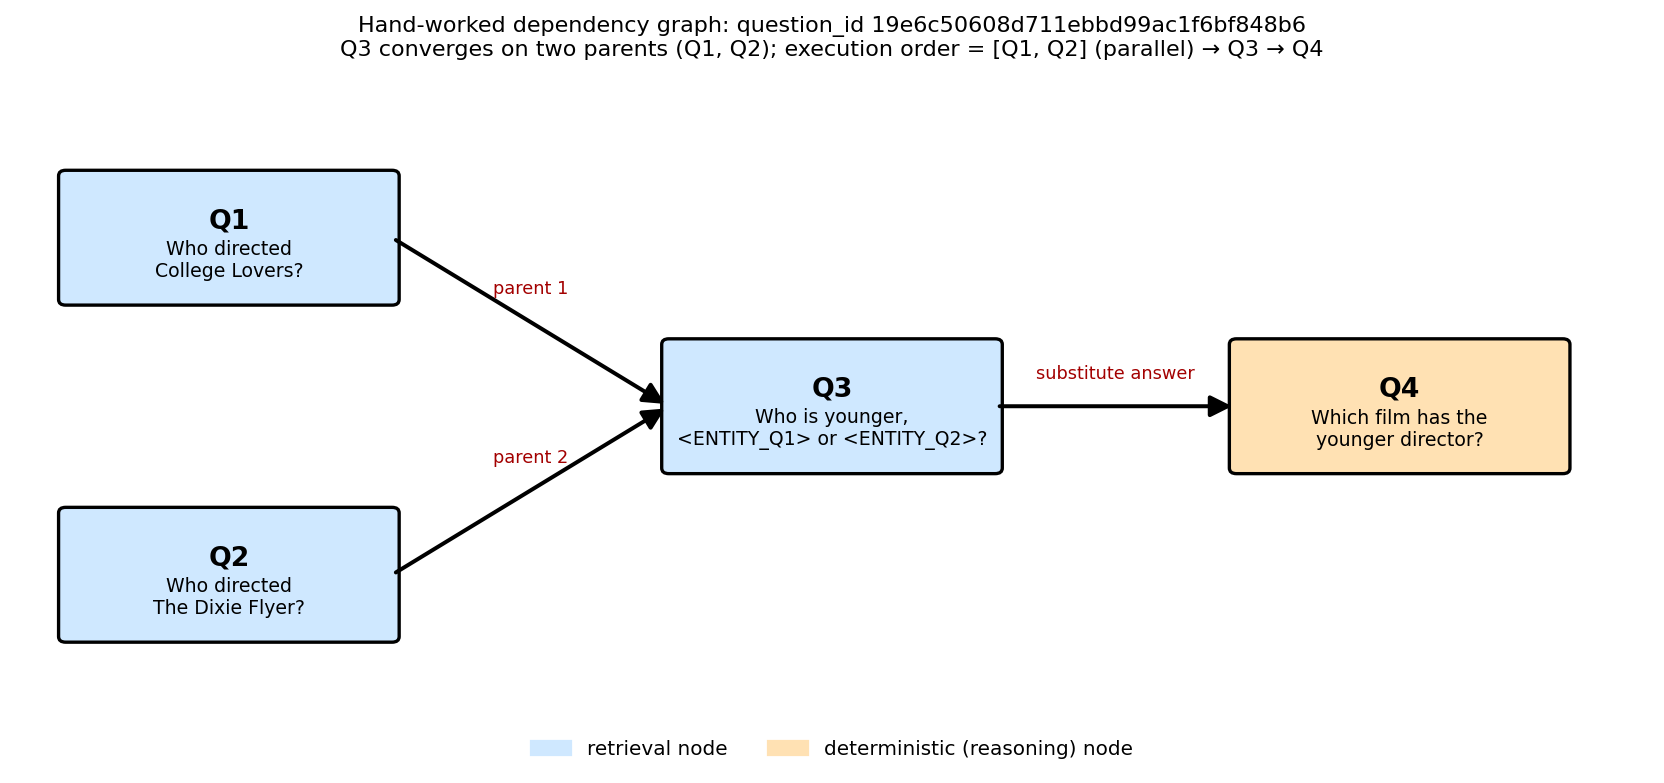

Q4's operation is reasoning, not retrieval: every fact it needs was already found by Q3, so it looks up known information rather than querying the corpus again. This is why `retrieval_components` reports Q4 separately as deterministic -- treating it as a retrieval hop would waste a candidate pool on a step needing no corpus access.



## Question 5 — sparse retrieval baselines (12 points)

Evaluate TF–IDF and BM25 for both direct QA retrieval and entity
retrieval followed by local GSW expansion. Use stable QA IDs for
relevance; do not evaluate by comparing array positions.

In [11]:
from panini_course import BM25Index, TfidfIndex
from panini_course.metrics import recall_at_k, reciprocal_rank

def load_sparse_artifacts(root):
    return {
        'qa_tfidf': TfidfIndex.load(
            root/'indices/qa_tfidf.npz',
            root/'indices/qa_tfidf_vectorizer.joblib',
            root/'indices/qa_ids.json', source='qa_tfidf'),
        'qa_bm25': BM25Index.load(
            root/'indices/qa_bm25.joblib',
            root/'indices/qa_ids.json', source='qa_bm25'),
        'entity_tfidf': TfidfIndex.load(
            root/'indices/entity_tfidf.npz',
            root/'indices/entity_tfidf_vectorizer.joblib',
            root/'indices/entity_ids.json', source='entity_tfidf'),
        'entity_bm25': BM25Index.load(
            root/'indices/entity_bm25.joblib',
            root/'indices/entity_ids.json', source='entity_bm25'),
    }

sparse = {name: load_sparse_artifacts(root) for name, root in PACKAGE_ROOTS.items()}

def evaluate_sparse_retrieval(dataset, package, artifacts, k_values=(1, 5, 10, 15)):
    # TODO Q5: evaluate atomic gold retrieval tasks overall and by
    # question type/hop count. Include latency and failure examples.
    raise NotImplementedError('Implement the sparse baseline evaluator')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### Your written response for Question 5

Replace this cell with a **150–200-word explanation in your own words**.
Compare TF–IDF and BM25 using both aggregate metrics and concrete successes/failures. Explain which wording or token-frequency properties caused the difference.

> **Write your response here.** Do not leave a list of numbers without
> interpreting what they mean and what could have caused them.

## Question 6 — dense, hybrid, and paper-style dual retrieval (16 points)

All corpus and required query embeddings are supplied. Load them by
stable ID and exact query text. A missing required query means your
deterministic plan or RICR path diverged; it is not permission to
generate a new embedding.

In [12]:
from panini_course import (
    DenseIndex, DualRetriever, QueryEmbeddingStore,
    reciprocal_rank_fusion,
)

def load_dense_artifacts(root):
    query_store = QueryEmbeddingStore.load(
        root/'embeddings/query_embeddings.npy',
        root/'embeddings/query_ids.json',
        root/'embeddings/queries.jsonl')
    return {
        'queries': query_store,
        'qa_dense': DenseIndex.load(
            root/'indices/qa_qwen3_8b_ip.faiss',
            root/'indices/qa_ids.json', source='qa_dense'),
        'entity_dense': DenseIndex.load(
            root/'indices/entity_qwen3_8b_ip.faiss',
            root/'indices/entity_ids.json', source='entity_dense'),
    }

dense = {name: load_dense_artifacts(root) for name, root in PACKAGE_ROOTS.items()}

def retrieve_candidate_pool(dataset, query, pool_size=RETRIEVAL_POOL, backend='dual'):
    # TODO Q6:
    # - implement direct dense QA, RRF, and paper-style dual retrieval;
    # - dual retrieval is BM25 entity search + local GSW QA expansion
    #   unioned with direct dense QA retrieval;
    # - deduplicate by qa_uid and retain provenance/ranks;
    # - return QA records ready for Question 7 reranking.
    raise NotImplementedError('Implement dense, RRF, and dual candidate retrieval')

# TODO Q6: manually verify FAISS inner products for five supplied
# query vectors, then evaluate all retrieval variants consistently.

### Your written response for Question 6

Replace this cell with a **200–300-word explanation in your own words**.
Use the measured tables to explain where dense retrieval, RRF, and entity expansion help or hurt. Include candidate-set overlap and at least one error attributable to the retrieval pool rather than reranking.

> **Write your response here.** Do not leave a list of numbers without
> interpreting what they mean and what could have caused them.

## Stage B — Question 7: reranking without exceeding Colab memory (8 points)

The reranker is the only neural model in this stage. Use the 8B
checkpoint in 4-bit mode when it fits; after an actual CUDA OOM,
clear memory and use the configured 4B fallback with batch size 1
and 256-token inputs. Cache rankings by exact instantiated query so
RICR replay and ablations do not rerun the same model call.

In [13]:
from panini_course import Candidate

def format_qa_for_reranker(qa_row):
    # TODO Q7: format only the grounded QA record and its answer
    # role/state information. Do not pass source documents.
    raise NotImplementedError('Format one QA candidate')

def rerank_and_convert(dataset, query, reranker, *, top_k=CANDIDATES_PER_HOP):
    # TODO Q7:
    # 1. retrieve a union pool with retrieve_candidate_pool;
    # 2. score its formatted QA records with QwenReranker;
    # 3. combine/calibrate retrieval and reranker scores as specified;
    # 4. return Candidate objects, one per QA, keeping all answers;
    # 5. namespace each local answer ID with document/GSW provenance.
    raise NotImplementedError('Implement reranking and Candidate conversion')

def choose_reranker_config(model_cfg):
    try:
        import torch
        total_gib = torch.cuda.get_device_properties(0).total_memory / 2**30
    except Exception:
        total_gib = 0.0
    use_8b = total_gib >= model_cfg['reranker']['use_8b_at_or_above_gib']
    return {
        'model': (model_cfg['reranker']['model'] if use_8b
                  else model_cfg['reranker']['free_colab_t4_fallback']),
        'batch_size': 1 if total_gib < 20 else 8,
        'max_length': 256 if total_gib < 20 else 2048,
        'total_gib': total_gib,
    }

### Your written response for Question 7

Replace this cell with a **150–200-word explanation in your own words**.
State whether reranking improved the candidate order and whether it changed complete-pool recall. Show a case where reranking demoted a strong exact match or promoted a semantically better candidate.

> **Write your response here.** Do not leave a list of numbers without
> interpreting what they mean and what could have caused them.

## Question 8 — implement connected-DAG RICR (22 points)

Complete `panini_course/ricr.py`, not an alternative linear search
in this notebook. Your implementation must combine all parents at a
converging node, use harmonic-mean parent combinations and the 0.3
threshold/fallback, group intermediate answer entities, retain
final-hop QA alternatives, and gather evidence from all final
beams. Run the supplied tests before starting Stage B.

In [14]:
# In Colab, edit PERSISTENT_RICR and PERSISTENT_TESTS through the
# file browser, then rerun from setup to sync ricr.py into the clone.
# These tests are skipped until the two scaffold functions no longer
# raise NotImplementedError, then turn on automatically.
test_root = REPO_ROOT / 'tests'
subprocess.run(
    [sys.executable, '-m', 'pytest', '-q', str(test_root)],
    check=False,
)

from panini_course import run_panini_ricr

toy_plan = [
    {'question': 'Who directed Film A?', 'requires_retrieval': True},
    {'question': 'Who directed Film B?', 'requires_retrieval': True},
    {'question': 'Who was born later, <ENTITY_Q1> or <ENTITY_Q2>?',
     'requires_retrieval': True},
]
# TODO Q8: add hand-calculable candidates, execute this converging
# DAG, and assert its issued query, beam scores, and evidence set.

In [15]:
# Stage B: the completed RICR implementation drives dynamic queries.
if RUN_RERANK_AND_RICR_STAGE:
    from dataclasses import asdict
    from panini_course.qwen_models import QwenReranker

    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    selected = choose_reranker_config(model_cfg)
    print('reranker selection:', selected)
    try:
        reranker = QwenReranker(
            selected['model'], quantized=True,
            max_length=selected['max_length'])
    except RuntimeError as error:
        if 'out of memory' not in str(error).casefold():
            raise
        release_gpu()
        selected.update({
            'model': model_cfg['reranker']['free_colab_t4_fallback'],
            'batch_size': 1,
            'max_length': 256,
        })
        reranker = QwenReranker(
            selected['model'], quantized=True, max_length=256)
    try:
        for dataset, package in packages.items():
            output = WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl'
            done = completed_ids(output, configuration='default')
            plans = {row['question_id']: row for row in read_jsonl(
                WORK_ROOT / 'cache' / dataset / 'decompositions.jsonl')}
            for question in selected_questions(package):
                qid = str(question['question_id'])
                if qid in done:
                    continue
                plan_row = plans.get(qid)
                if not plan_row or not plan_row.get('decomposition_valid'):
                    append_jsonl(output, {
                        'dataset': dataset, 'configuration': 'default',
                        'question_id': qid, 'error': 'invalid decomposition'})
                    continue
                started = time.perf_counter()
                result = run_panini_ricr(
                    plan_row['predicted_decomposition'],
                    lambda query, k: rerank_and_convert(
                        dataset, query, reranker, top_k=k),
                    original_question=question['question'],
                    beam_width=BEAM_WIDTH,
                    candidates_per_hop=CANDIDATES_PER_HOP,
                    multi_dependency_threshold=MULTI_PARENT_THRESHOLD,
                )
                append_jsonl(output, {
                    'dataset': dataset,
                    'configuration': 'default',
                    'question_id': qid,
                    'question': question['question'],
                    'reranker_model': selected['model'],
                    'trace': asdict(result),
                    'retrieval_seconds': time.perf_counter() - started,
                    'error': None,
                })
                done.add(qid)
    finally:
        del reranker
        release_gpu()
else:
    print('Stage B disabled. Complete Questions 6–8 first.')

Stage B disabled. Complete Questions 6–8 first.


### Your written response for Question 8

Replace this cell with a **200–300-word explanation in your own words**.
Show your hand calculation and explain why independent linear branches are not equivalent to executing a converging retrieval DAG. Identify where beam diversity is gained or lost.

> **Write your response here.** Do not leave a list of numbers without
> interpreting what they mean and what could have caused them.

## Question 9 — controlled RICR ablations (14 points)

Change one factor at a time on the fixed 20-question ablation slice.
Reuse cached candidate rankings whenever the instantiated query and
backend are unchanged. Do not compare a warm cache time with an
uncached model time as if they were equivalent.

In [16]:
ablation_configs = [
    {'name': 'default', 'beam': 5, 'k': 15, 'backend': 'dual',
     'unique': True, 'score': 'geometric', 'parent_threshold': 0.3},
    {'name': 'beam_1', 'beam': 1},
    {'name': 'beam_3', 'beam': 3},
    {'name': 'k_5', 'k': 5},
    {'name': 'unique_off', 'unique': False},
    {'name': 'last_hop', 'score': 'last_hop'},
    {'name': 'parent_threshold_off', 'parent_threshold': 0.0},
    {'name': 'bm25', 'backend': 'bm25'},
    {'name': 'dense', 'backend': 'dense'},
    {'name': 'rrf', 'backend': 'rrf'},
]

def run_ablation(configuration, dataset, questions):
    # TODO Q9: merge each partial dictionary with the default,
    # execute exactly the same fixed questions, append traces, and
    # report chain recovery, answer metrics, evidence size, and a
    # valid cold or consistently cached latency measurement.
    raise NotImplementedError('Implement the controlled ablation runner')

if RUN_ABLATIONS:
    require_full_run()
    # TODO Q9: use the first 20 public questions from each dataset.
    raise NotImplementedError('Run and checkpoint every ablation')

### Your written response for Question 9

Replace this cell with a **250–350-word explanation in your own words**.
Use the measured table to recommend a configuration. Discuss accuracy, chain recovery, latency, and at least one interaction that a one-factor ablation cannot establish.

> **Write your response here.** Do not leave a list of numbers without
> interpreting what they mean and what could have caused them.

## Stage C — Question 10: end-to-end 2Wiki evaluation (10 points)

Stage C reads saved RICR traces and loads only Qwen3-4B. The answer
model receives deduplicated QA evidence from every surviving final
beam, including role/state strings. It must not receive source
documents, graph neighbors, or gold labels. The supplied wrapper
already implements the required four-message one-shot PANINI prompt;
do not add an `N/A` instruction for these answerable splits.

In [17]:
from panini_course.metrics import exact_match, token_f1

def format_evidence(candidate):
    # TODO Q10: produce one grounded line containing stored question,
    # all answer names, and answer role/state strings. Do not include
    # source passages or gold final answers.
    raise NotImplementedError('Format answer-model evidence')

if RUN_ANSWER_STAGE:
    from panini_course.qwen_models import QwenAnswerer

    model_cfg = json.loads((PACKAGE_ROOTS['2wiki'] / 'models/model_config.json').read_text())
    answerer = QwenAnswerer(model_cfg['answer_model']['model'], quantized=True)
    try:
        for dataset, package in packages.items():
            traces = {row['question_id']: row for row in read_jsonl(
                WORK_ROOT / 'cache' / dataset / 'ricr_traces.jsonl')
                if row.get('configuration') == 'default'}
            output = WORK_ROOT / 'cache' / dataset / 'answers.jsonl'
            done = completed_ids(output)
            for question in selected_questions(package):
                qid = str(question['question_id'])
                if qid in done or qid not in traces:
                    continue
                trace = traces[qid]
                if trace.get('error'):
                    continue
                evidence_rows = trace['trace']['evidence']
                evidence = [format_evidence(row) for row in evidence_rows]
                started = time.perf_counter()
                generated = answerer.answer_with_trace(question['question'], evidence)
                record = {
                    'dataset': dataset,
                    'question_id': qid,
                    'question': question['question'],
                    'predicted_answer': generated['answer'],
                    'raw_answer_response': generated['response'],
                    'answer_evidence': evidence,
                    'answer_seconds': time.perf_counter() - started,
                }
                if 'answer' in question:
                    gold = [question['answer'], *question.get('answer_aliases', [])]
                    record['exact_match'] = exact_match(generated['answer'], gold)
                    record['token_f1'] = token_f1(generated['answer'], gold)
                append_jsonl(output, record)
                done.add(qid)
    finally:
        del answerer
        release_gpu()
else:
    print('Stage C disabled. Complete and checkpoint Stage B first.')

Stage C disabled. Complete and checkpoint Stage B first.


In [18]:
def score_default_run(dataset, package):
    # TODO Q10/Q11: join plans, traces, answers, and public labels by
    # question_id. Compute supporting-QA/document recall,
    # complete-chain recovery, EM/F1, evidence size, and latency;
    # summarize 2Wiki by type and MuSiQue by hop_count.
    raise NotImplementedError('Implement end-to-end scoring')

# TODO Q10: display the overall and per-type 2Wiki tables, plus one
# successful and one failed trace with the first irreversible error.

### Your written response for Question 10

Replace this cell with a **250–350-word explanation in your own words**.
Interpret the 2Wiki result by failure stage: decomposition, candidate recall, later-hop substitution/pruning, or answer generation. A correct final answer does not by itself prove complete-chain recovery.

> **Write your response here.** Do not leave a list of numbers without
> interpreting what they mean and what could have caused them.

## Question 11 — MuSiQue transfer and scaling (12 points)

Freeze all 2Wiki choices before inspecting MuSiQue results. Use the
same decomposition prompt, retrieval settings, beam rules,
reranker, answer prompt, and metrics. Compare 2-, 3-, and 4-hop
questions without tuning on MuSiQue labels.

In [19]:
# TODO Q11: run score_default_run for MuSiQue, display results by
# hop_count, and plot both complete-chain recovery and answer F1 as
# chain length increases. Attribute errors using saved traces.

# Example shape only; replace with your measured dataframe.
musique_by_hop = pd.DataFrame(columns=[
    'hop_count', 'questions', 'supporting_qa_recall',
    'complete_chain_recovery', 'EM', 'F1'])
display(musique_by_hop)

,hop_count,questions,supporting_qa_recall,complete_chain_recovery,EM,F1


### Your written response for Question 11

Replace this cell with a **250–350-word explanation in your own words**.
Explain why complete-chain recovery is conjunctive while answer F1 is not. Separate the effect of hop count from dataset wording, entity distribution, and GSW coverage.

> **Write your response here.** Do not leave a list of numbers without
> interpreting what they mean and what could have caused them.

## Question 12 — reproducibility and final submission (12 points)

Materialize exactly four submission files: 80 labeled development
results and 20 label-free held-out predictions for each dataset.
Verify counts by stable question ID, not just line count. Record the
environment, frozen configuration, model IDs, resume instructions,
and which timings were cold versus cache replay.

In [20]:
SUBMISSION_ROOT = WORK_ROOT / 'submission'
required_files = {
    SUBMISSION_ROOT/'results/2wiki_dev.jsonl': 80,
    SUBMISSION_ROOT/'predictions/2wiki_heldout.jsonl': 20,
    SUBMISSION_ROOT/'results/musique_dev.jsonl': 80,
    SUBMISSION_ROOT/'predictions/musique_heldout.jsonl': 20,
}

def materialize_submission(dataset, package):
    # TODO Q12: split cached answers by the package's public and
    # held-out ID sets. Development rows include metrics; held-out
    # rows contain only IDs, questions, predictions, and allowed
    # trace/runtime metadata. Never copy labels into held-out files.
    raise NotImplementedError('Write the required submission files')

def validate_submission_file(path, expected, allowed_heldout_fields=None):
    # TODO Q12: uniqueness, exact ID-set match, count, valid JSON,
    # finite metrics, and held-out field allowlist checks.
    raise NotImplementedError('Implement final submission validation')

if QUESTION_LIMIT is None and all(path.exists() for path in required_files):
    for path, expected in required_files.items():
        validate_submission_file(path, expected)
    print('All required submission files validated.')
else:
    print('Final validation waits until QUESTION_LIMIT=None and all files exist.')

Final validation waits until QUESTION_LIMIT=None and all files exist.


In [21]:
# TODO Q12: write environment.txt and RUNME.md. Include at least:
environment = {
    'python': sys.version,
    'platform': platform.platform(),
    'question_limit': QUESTION_LIMIT,
    'beam_width': BEAM_WIDTH,
    'candidates_per_hop': CANDIDATES_PER_HOP,
    'retrieval_pool': RETRIEVAL_POOL,
    'rrf_constant': RRF_CONSTANT,
    'multi_parent_threshold': MULTI_PARENT_THRESHOLD,
    'package_manifests': {
        name: package.manifest for name, package in packages.items()
    },
}
(WORK_ROOT/'environment.json').write_text(
    json.dumps(environment, indent=2, ensure_ascii=False), encoding='utf-8')
print('environment:', WORK_ROOT/'environment.json')

environment: /content/drive/MyDrive/panini-course-project-work/environment.json


### Your written response for Question 12

Replace this cell with a **300–450-word explanation in your own words**.
Tell the complete system story from input question to final answer, identify the design’s main protection and main failure mode, and explain how another student can resume and reproduce your run.

> **Write your response here.** Do not leave a list of numbers without
> interpreting what they mean and what could have caused them.

## Final pre-submission checklist

- [ ] `QUESTION_LIMIT` was set to `None` for final runs.
- [ ] All supplied tests pass, plus your reconciliation and failure-case tests.
- [ ] Every expensive stage resumes from JSONL by stable question ID.
- [ ] Only one Qwen model was resident at a time.
- [ ] No embeddings were generated.
- [ ] The 2Wiki configuration was frozen before MuSiQue evaluation.
- [ ] All twelve written-response cells were replaced with your own analysis.
- [ ] Held-out outputs contain no answer, alias, or supporting-evidence labels.
- [ ] Four required JSONL files, the executed notebook, figures, tests,
  `environment.json`, and `RUNME.md` are included.